# Packages + Data Load

In [2]:
import kagglehub
from dotenv import load_dotenv
import os

import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.special import inv_boxcox

c:\Users\RobertMorsch\Practice_Projects\Ames-House-Prices\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from dotenv import load_dotenv
import os

# 1. Load variables from .env into the environment
load_dotenv() 

# 2. Access them using the standard OS library
kaggle_user = os.getenv('KAGGLE_USERNAME')
kaggle_key = os.getenv('KAGGLE_KEY')

# Download the latest version of the competition data
path = kagglehub.competition_download("house-prices-advanced-regression-techniques")

print("Path to competition files:", path)

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv(os.path.join(path, "train.csv"))
df_test = pd.read_csv(os.path.join(path, "test.csv"))

Path to competition files: C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\data_description.txt
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\sample_submission.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\test.csv
C:\Users\RobertMorsch\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques\train.csv


# Overall look

In [4]:

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
df.info()
df.head()

Number of rows: 1460
Number of columns: 81
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Null Handling

In [5]:
series = df.isna().sum().sort_values(ascending=False)
print(len(series[series > 0]))
series[series > 0]


19


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
GarageYrBlt       81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtCond          37
BsmtQual          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

Didn't know this but a lot of these Nulls aren't actually Nulls, but pandas readcsv actually reads certain values ("NA", "None") as nulls. Rather than updating the read statement just going to handle them explicilty.

In [6]:
# Columns where NA is intentional to mean "Absent"
na_means_absent_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu',
                         'GarageQual', 'GarageFinish', 'GarageType', 'GarageCond', 'BsmtFinType2', 'BsmtExposure', 
                         'BsmtCond', 'BsmtQual', 'BsmtFinType1']
# Columns where NA is likely missing data that should be  inferrable
# GarageYrBlt - likely can be inferred from GarageType or GarageFinish
# LotFrontage - NOT clear where it can be inferred, but null may just mean no frontage
# MasVnrArea - likely can be inferred from MasVnrType
# Electrical
na_means_missing_cols_but_inferrable = ['GarageYrBlt','LotFrontage', 'MasVnrArea']
# Columns where NA is likely missing data and needs imputation
na_means_missing_cols = ['Electrical']

print("NA Columns where NA means Absent:", len(na_means_absent_cols))
print("NA Columns where NA means Missing but Inferrable:", len(na_means_missing_cols_but_inferrable))
print("NA Columns where NA means Missing:", len(na_means_missing_cols))
na_series = df.isna().sum().sort_values(ascending=False)
len(series[series > 0]) == len(na_means_absent_cols) + len(na_means_missing_cols_but_inferrable) + len(na_means_missing_cols)

# Check that NA missings for inferrables are in fact inferrable
for col in na_means_missing_cols_but_inferrable:
    if col == 'GarageYrBlt': # likely can be inferred from GarageType or GarageFinish, if GarageType is NA then it likely means no garage and thus GarageYrBlt should be 0
        df.loc[df['GarageType'].isna(), 'GarageYrBlt'] = 0
    elif col == 'LotFrontage': # doesnt appear to be inferrable, but null may just mean no frontage, may come back to this
        df.loc[df['LotFrontage'].isna(), 'LotFrontage'] = 0 
    elif col == 'MasVnrArea': # can be inferred from MasVnrType, if MasVnrType is NA then it likely means no masonry veneer and thus MasVnrArea should be 0
        df.loc[df['MasVnrType'].isna(), 'MasVnrArea'] = 0
df[na_means_missing_cols_but_inferrable].isna().sum().sort_values(ascending=False) # check that all NA values have been filled for the inferrable columns

# Fill NA values for columns where NA means Absent with "None"
for col in na_means_absent_cols:
    df[col] = df[col].fillna("None")
    df_test[col] = df_test[col].fillna("None")

# Fill NA values for columns where NA means Missing with the mode value
for col in na_means_missing_cols: 
    df[col] = df[col].fillna(df[col].mode()[0])

assert df.isna().sum().sum() == 0, f"There are still NA values in the dataframe after imputation \n {series[series > 0]}"

NA Columns where NA means Absent: 15
NA Columns where NA means Missing but Inferrable: 3
NA Columns where NA means Missing: 1


# Cat and Num cols

In [7]:
print("Totals columns:", df.shape[1])
print("\n")
cat_cols = df.select_dtypes(include="str").columns
num_cols = df.select_dtypes(include="number").columns  

cat_cols_sorted = sorted(cat_cols)
print("Categorical columns:", np.array(cat_cols_sorted))
print("Number of categorical columns:", len(cat_cols_sorted))

Totals columns: 81


Categorical columns: ['Alley' 'BldgType' 'BsmtCond' 'BsmtExposure' 'BsmtFinType1'
 'BsmtFinType2' 'BsmtQual' 'CentralAir' 'Condition1' 'Condition2'
 'Electrical' 'ExterCond' 'ExterQual' 'Exterior1st' 'Exterior2nd' 'Fence'
 'FireplaceQu' 'Foundation' 'Functional' 'GarageCond' 'GarageFinish'
 'GarageQual' 'GarageType' 'Heating' 'HeatingQC' 'HouseStyle'
 'KitchenQual' 'LandContour' 'LandSlope' 'LotConfig' 'LotShape' 'MSZoning'
 'MasVnrType' 'MiscFeature' 'Neighborhood' 'PavedDrive' 'PoolQC'
 'RoofMatl' 'RoofStyle' 'SaleCondition' 'SaleType' 'Street' 'Utilities']
Number of categorical columns: 43


In [8]:
num_cols_sorted = sorted(num_cols)
print("Numerical columns:", np.array(num_cols_sorted))
print("Number of numerical columns:", len(num_cols_sorted))

Numerical columns: ['1stFlrSF' '2ndFlrSF' '3SsnPorch' 'BedroomAbvGr' 'BsmtFinSF1'
 'BsmtFinSF2' 'BsmtFullBath' 'BsmtHalfBath' 'BsmtUnfSF' 'EnclosedPorch'
 'Fireplaces' 'FullBath' 'GarageArea' 'GarageCars' 'GarageYrBlt'
 'GrLivArea' 'HalfBath' 'Id' 'KitchenAbvGr' 'LotArea' 'LotFrontage'
 'LowQualFinSF' 'MSSubClass' 'MasVnrArea' 'MiscVal' 'MoSold' 'OpenPorchSF'
 'OverallCond' 'OverallQual' 'PoolArea' 'SalePrice' 'ScreenPorch'
 'TotRmsAbvGrd' 'TotalBsmtSF' 'WoodDeckSF' 'YearBuilt' 'YearRemodAdd'
 'YrSold']
Number of numerical columns: 38


# Transformations

In [9]:
# Misclassifications
df['Id'] = df['Id'].astype(str)
df['MSSubClass'] = df['MSSubClass'].astype(str)

# Feature Engineering

In [10]:
df['YearBuilt_AGE'] = df['YrSold'] - df['YearBuilt']
df['YearReMod_AGE'] = df['YrSold'] - df['YearRemodAdd']
df['GarageYrBlt_AGE'] = df['YrSold'] - df['GarageYrBlt']

df['WasReModded'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)

# Response

<Axes: >

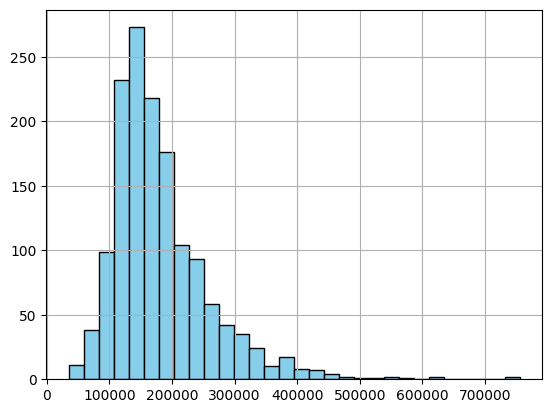

In [98]:
df['SalePrice'].hist(bins=30, color='skyblue', edgecolor='black')

In [12]:
print(f"Original skewness: {df['SalePrice'].skew():.4f}")

transformed_sale_price, lam = stats.boxcox(df['SalePrice'])
print(f"Transformed skewness: {pd.Series(transformed_sale_price).skew():.4f}")

Original skewness: 1.8829
Transformed skewness: -0.0087


# Graphing EDA

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 85 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Id               1460 non-null   str    
 1   MSSubClass       1460 non-null   str    
 2   MSZoning         1460 non-null   str    
 3   LotFrontage      1460 non-null   float64
 4   LotArea          1460 non-null   int64  
 5   Street           1460 non-null   str    
 6   Alley            1460 non-null   str    
 7   LotShape         1460 non-null   str    
 8   LandContour      1460 non-null   str    
 9   Utilities        1460 non-null   str    
 10  LotConfig        1460 non-null   str    
 11  LandSlope        1460 non-null   str    
 12  Neighborhood     1460 non-null   str    
 13  Condition1       1460 non-null   str    
 14  Condition2       1460 non-null   str    
 15  BldgType         1460 non-null   str    
 16  HouseStyle       1460 non-null   str    
 17  OverallQual      1460 non

In [95]:
cat_cols=df.select_dtypes(include=['str']).columns
num_cols = df.select_dtypes(include=['int64', 'float']).columns
print("Categorical Variables:")
print(cat_cols)
print("\n")
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['Id', 'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
       'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir',
       'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='str')


Numerical Variables:
Index(['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
       'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
       'BsmtFullBath', 'BsmtHalfBath', 'Ful

## Graphing Categoricals

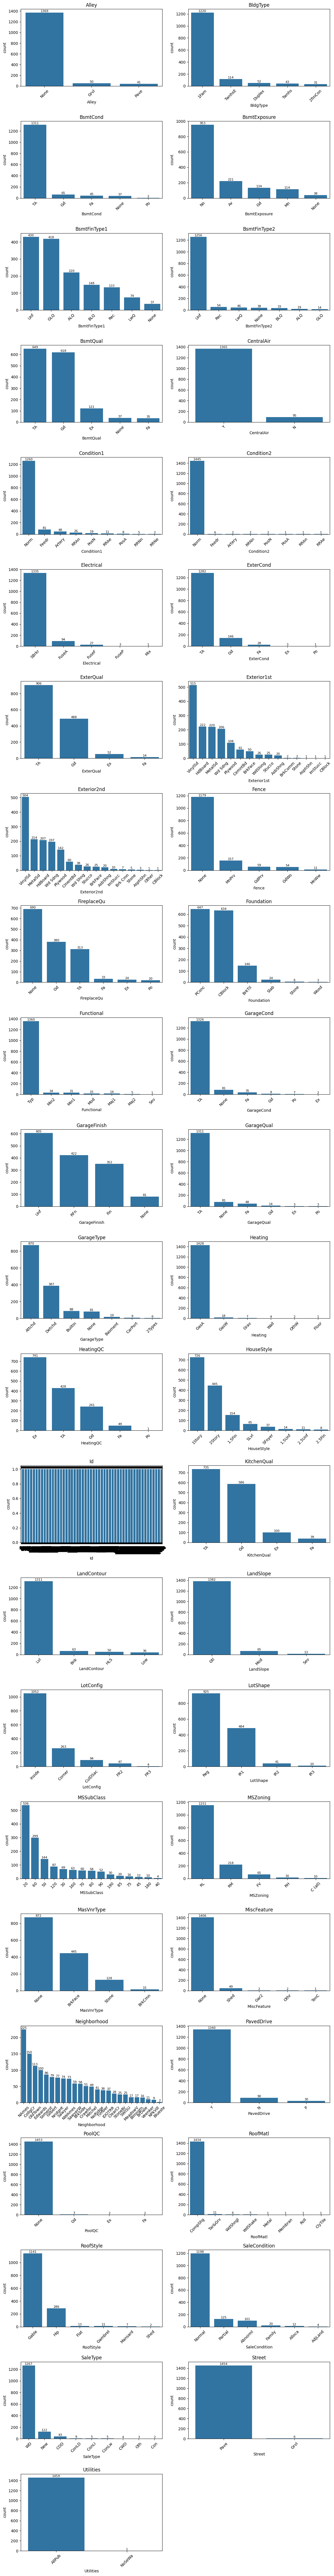

In [96]:
plots_per_row = 2

rows = math.ceil(len(cat_cols) / plots_per_row)

plt.figure(figsize=(12, rows * 4))

for i, col in enumerate(sorted(cat_cols), 1):
    plt.subplot(rows, plots_per_row, i)
    sns.countplot(data=df, x=col,
                  order=df[col].value_counts().index)
    # Add value labels
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt='%d', padding=0, fontsize=8)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.tight_layout()

plt.show()

## Graphing Numericals

LotFrontage
Skew : 0.27


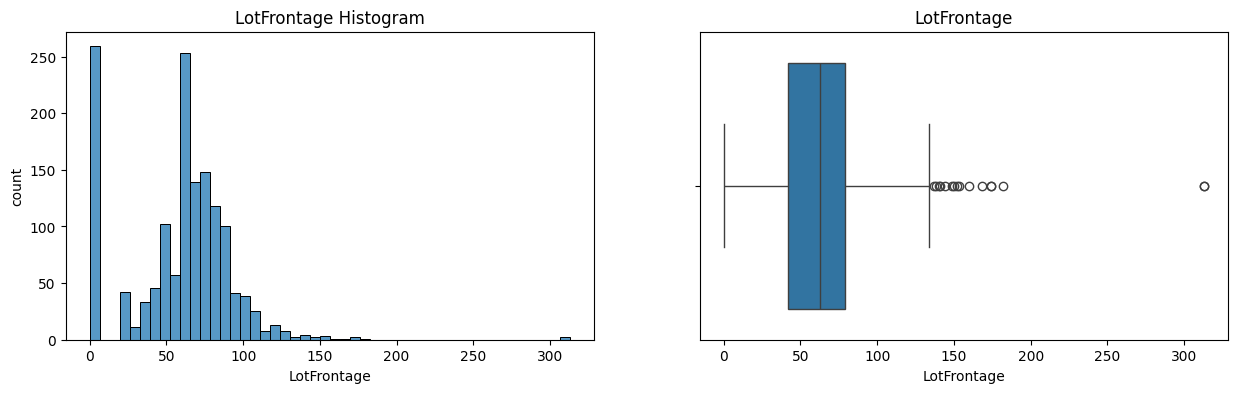

LotArea
Skew : 12.21


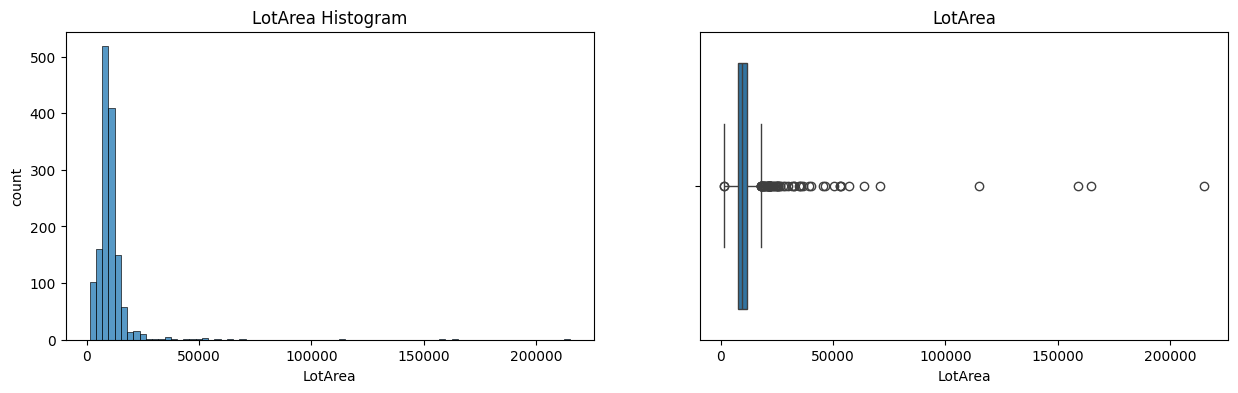

OverallQual
Skew : 0.22


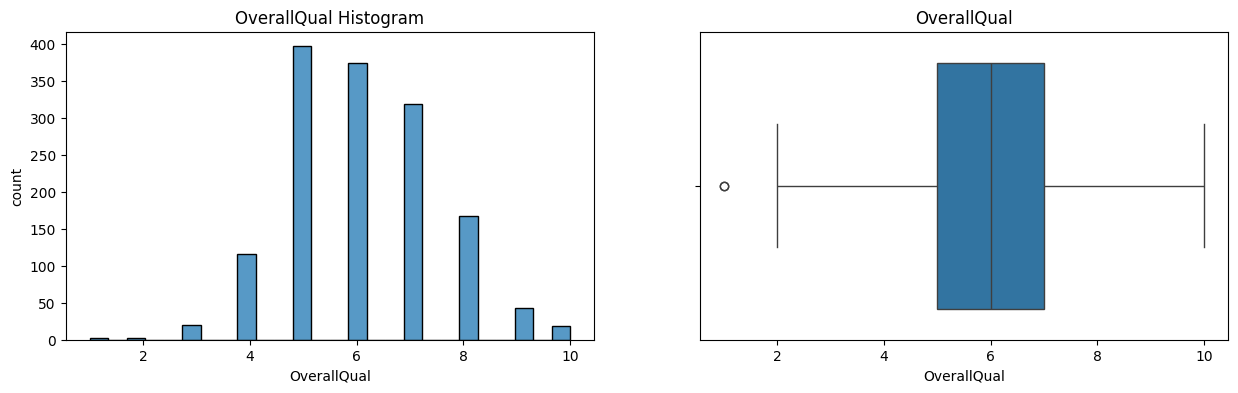

OverallCond
Skew : 0.69


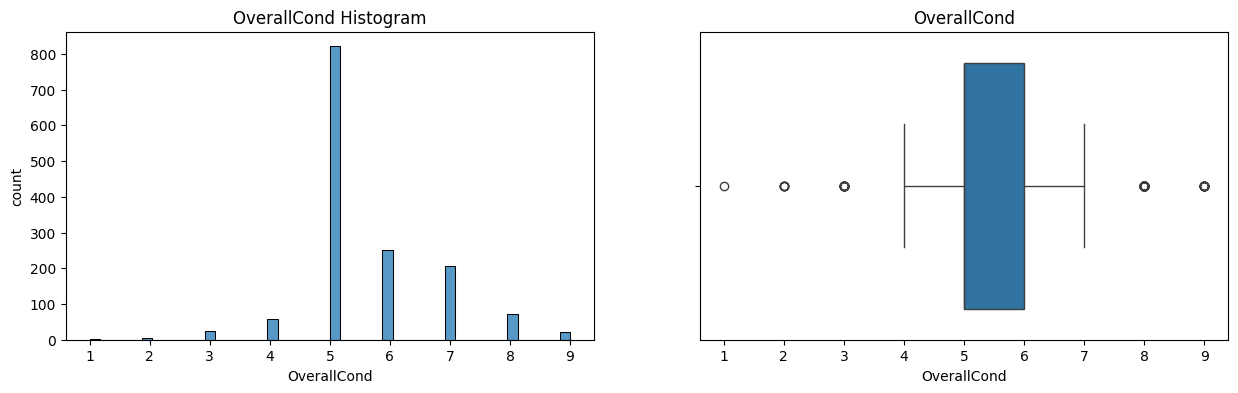

YearBuilt
Skew : -0.61


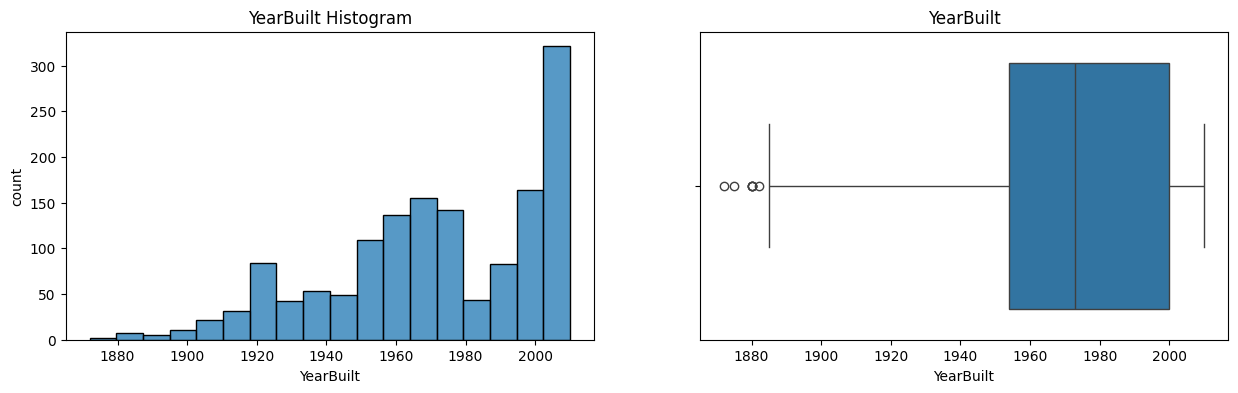

YearRemodAdd
Skew : -0.5


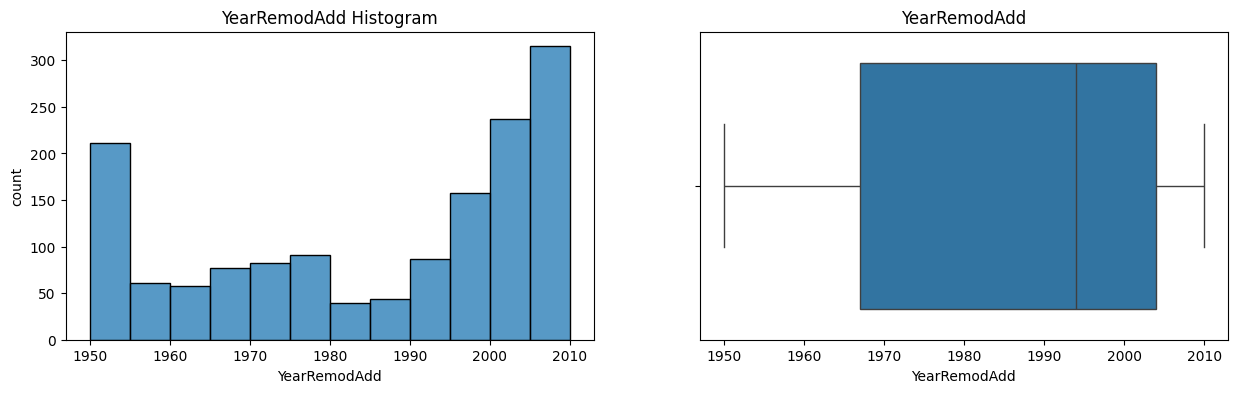

MasVnrArea
Skew : 2.69


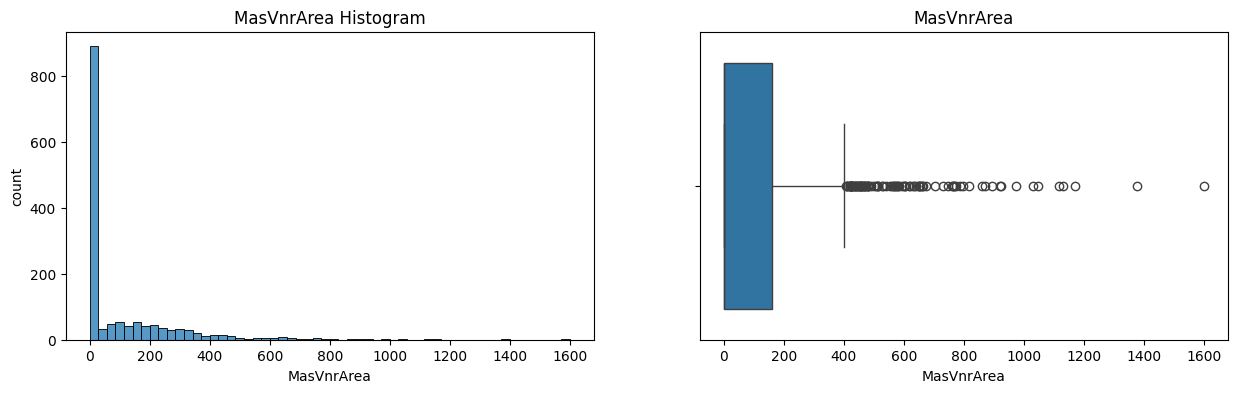

BsmtFinSF1
Skew : 1.69


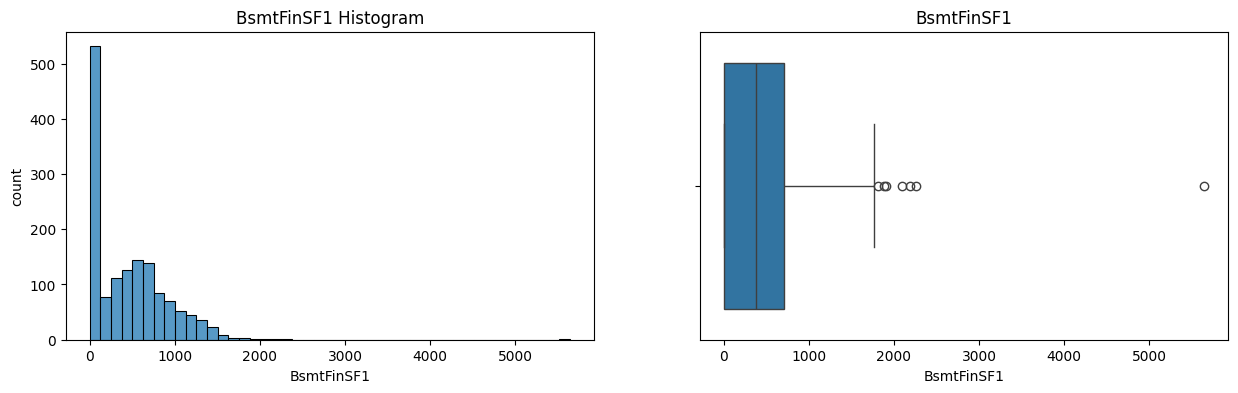

BsmtFinSF2
Skew : 4.26


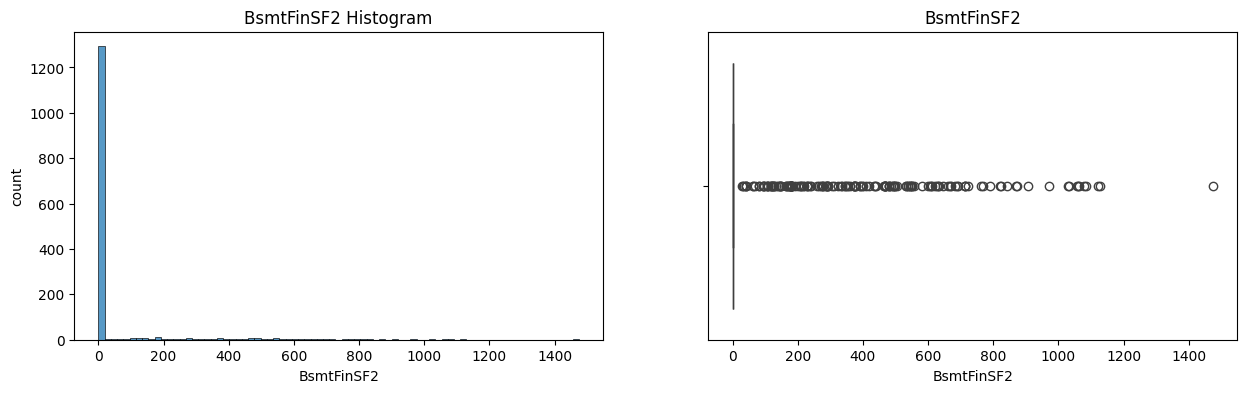

BsmtUnfSF
Skew : 0.92


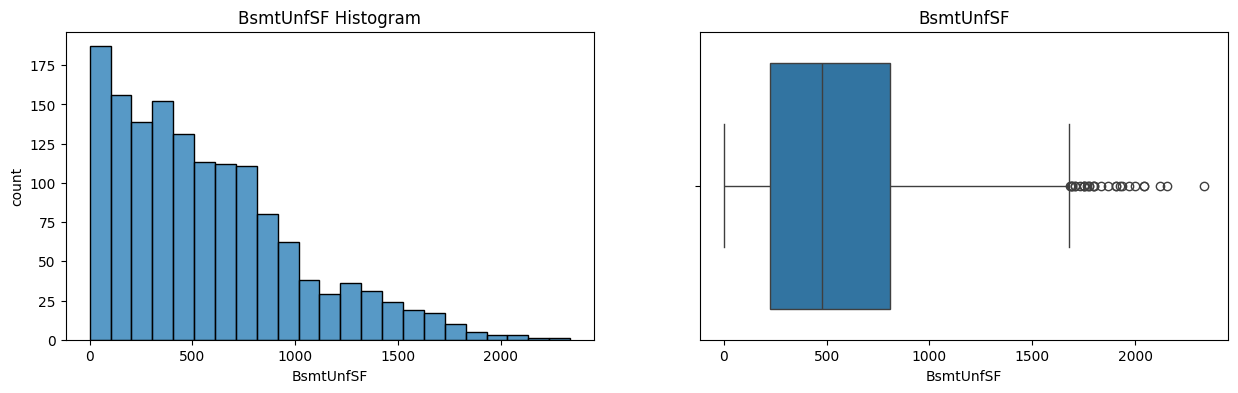

TotalBsmtSF
Skew : 1.52


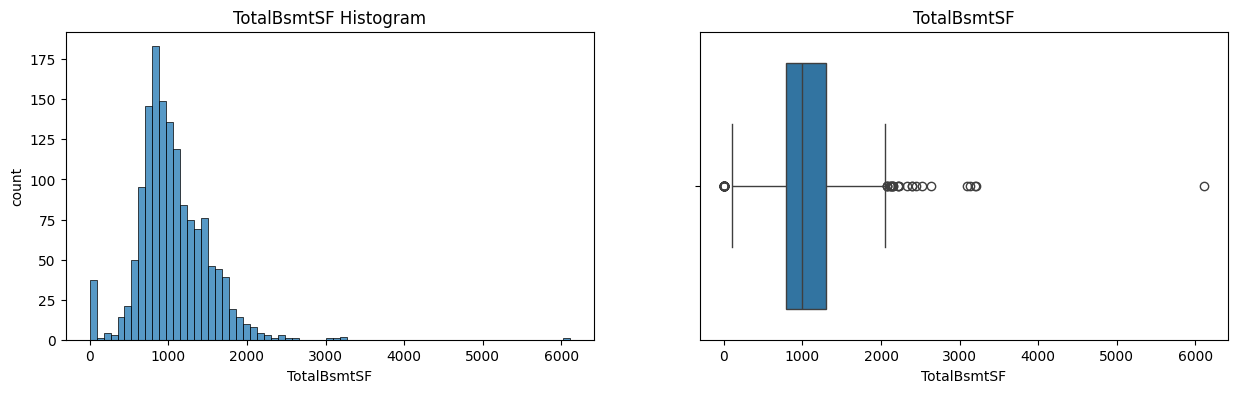

1stFlrSF
Skew : 1.38


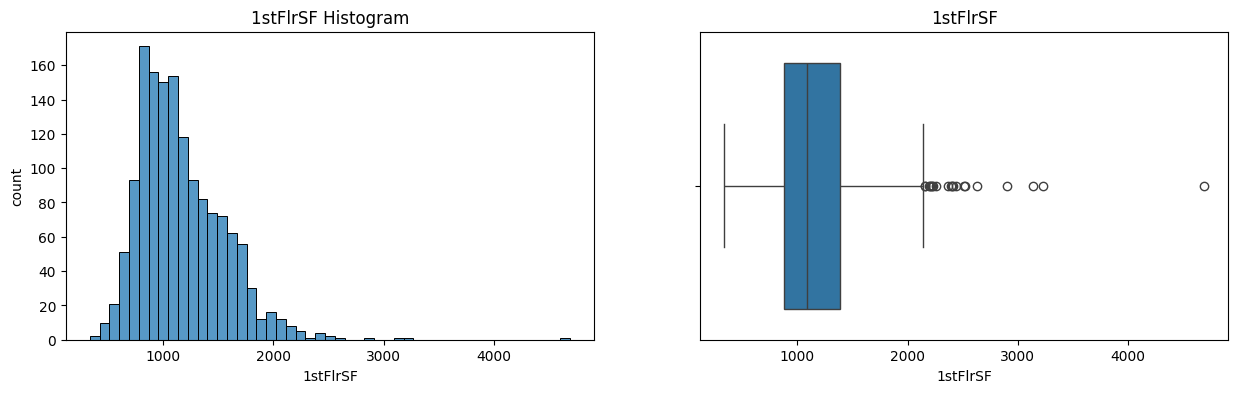

2ndFlrSF
Skew : 0.81


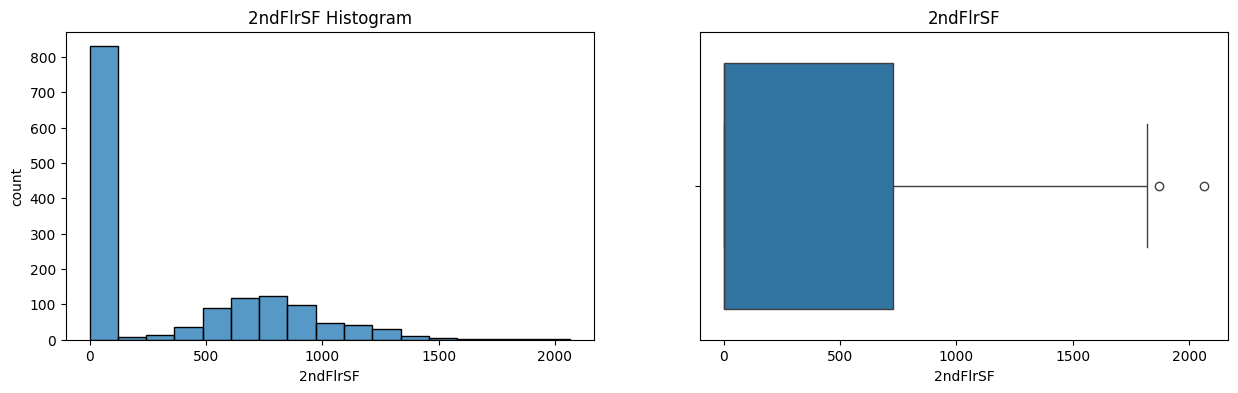

LowQualFinSF
Skew : 9.01


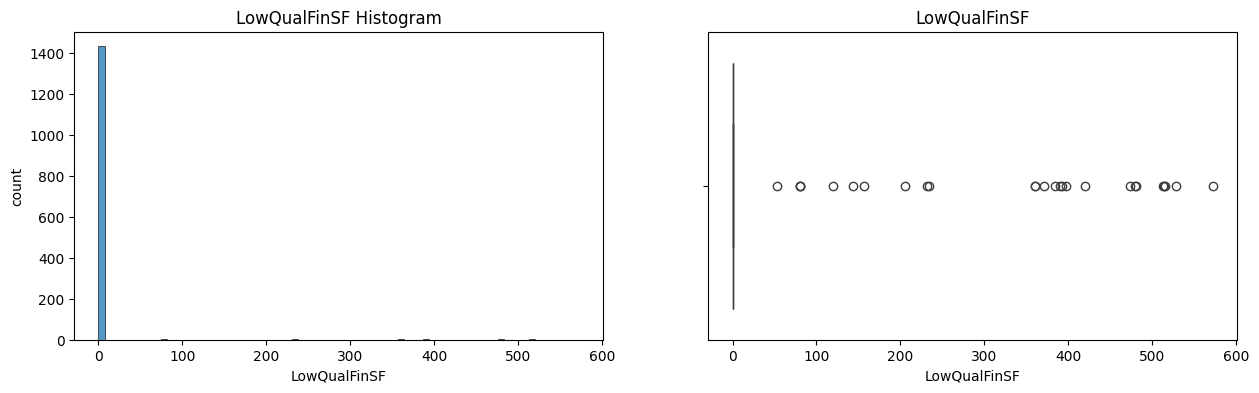

GrLivArea
Skew : 1.37


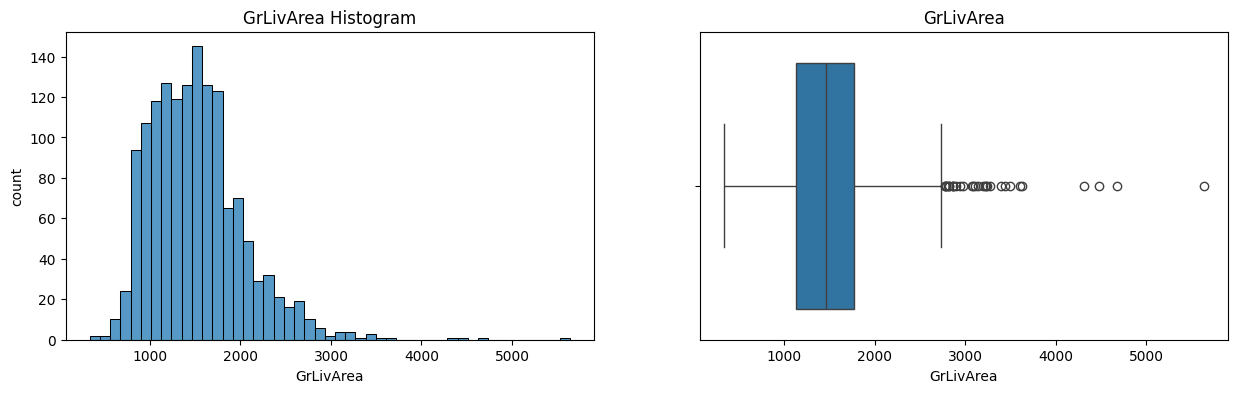

BsmtFullBath
Skew : 0.6


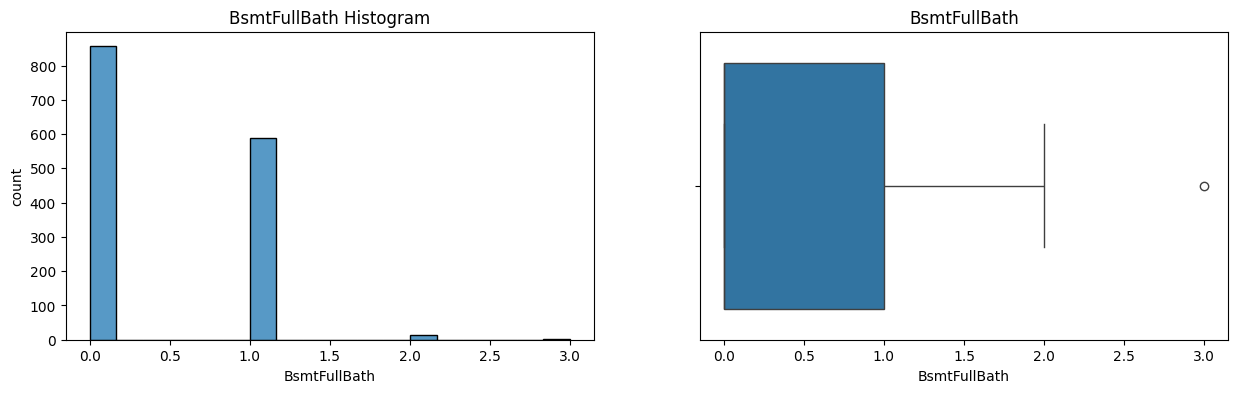

BsmtHalfBath
Skew : 4.1


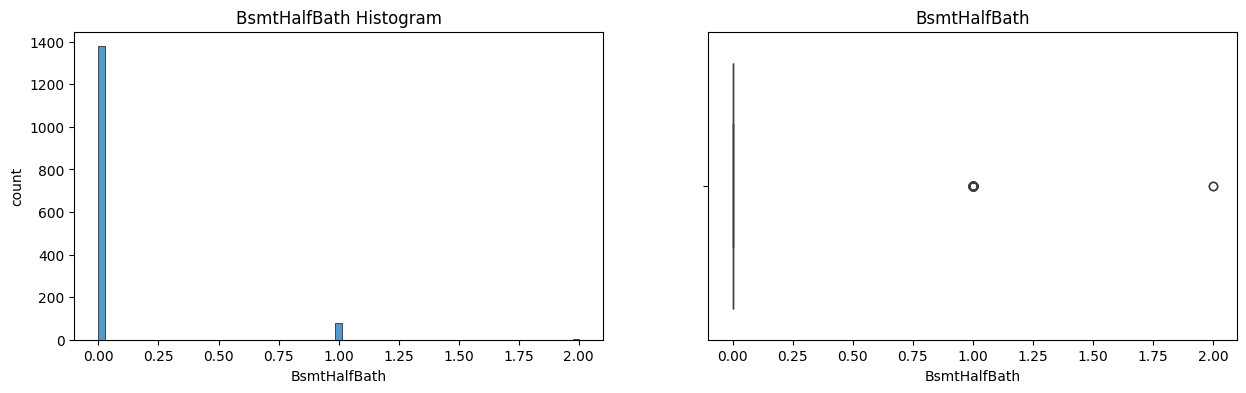

FullBath
Skew : 0.04


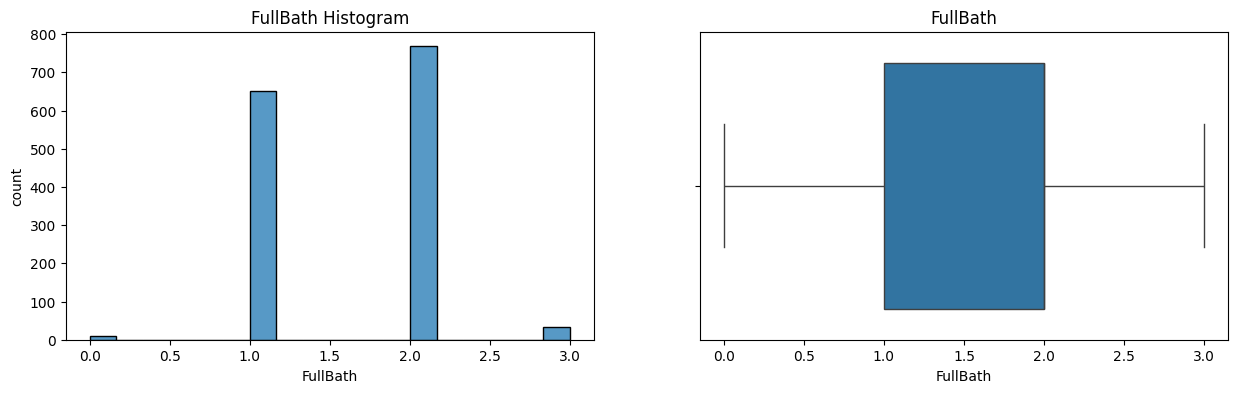

HalfBath
Skew : 0.68


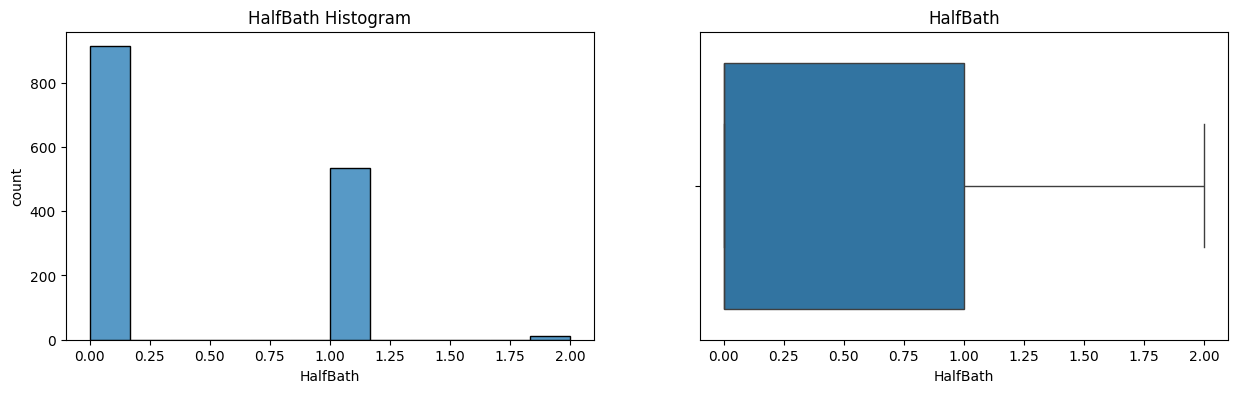

BedroomAbvGr
Skew : 0.21


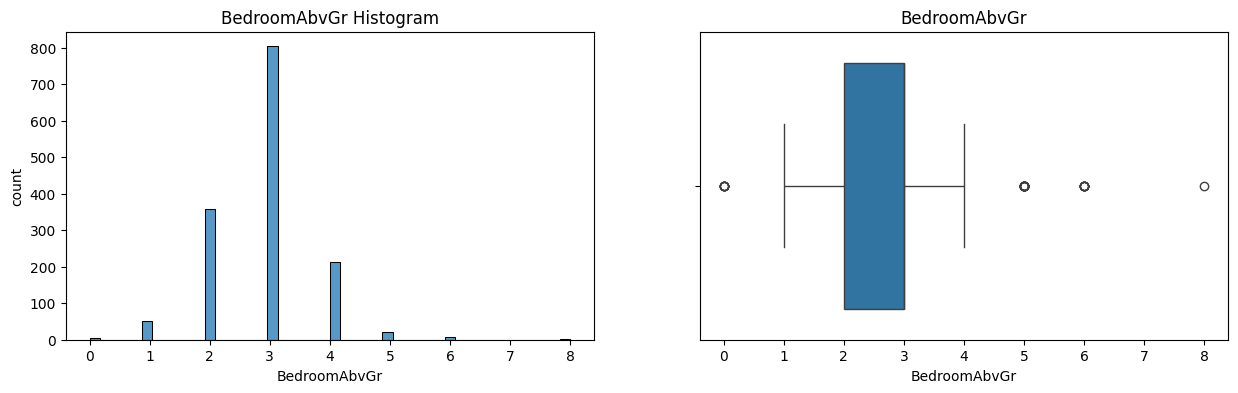

KitchenAbvGr
Skew : 4.49


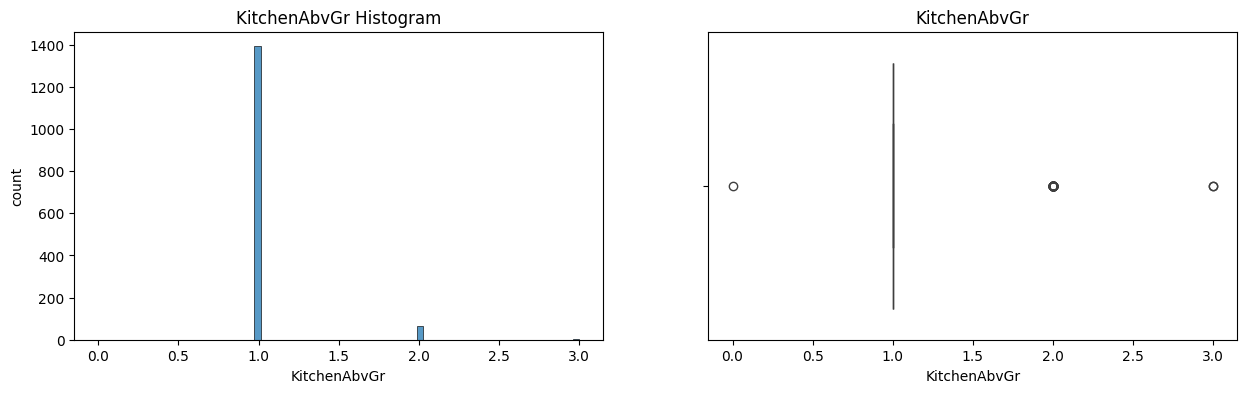

TotRmsAbvGrd
Skew : 0.68


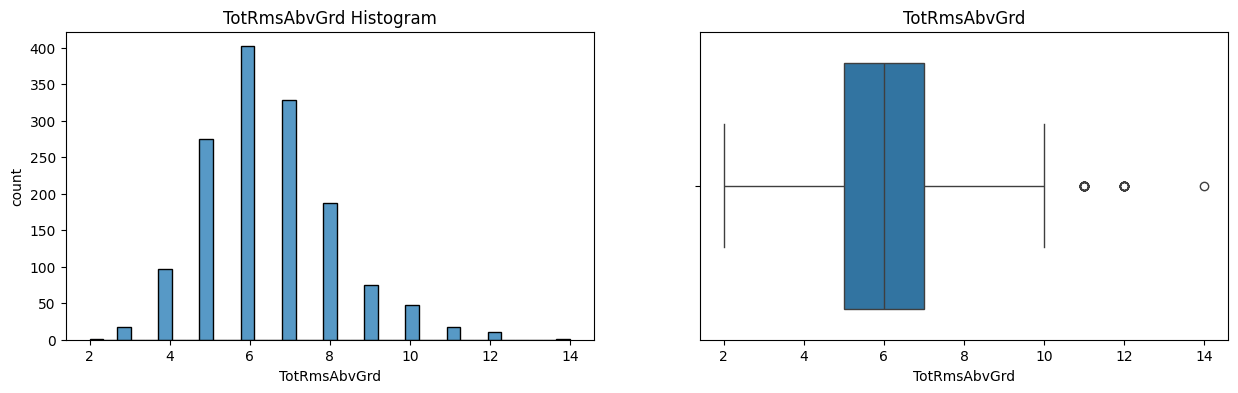

Fireplaces
Skew : 0.65


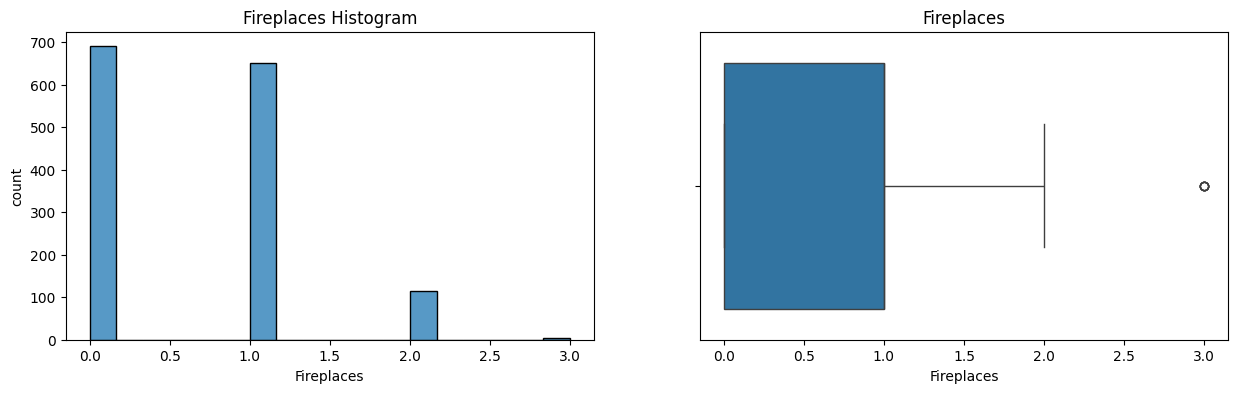

GarageYrBlt
Skew : -3.87


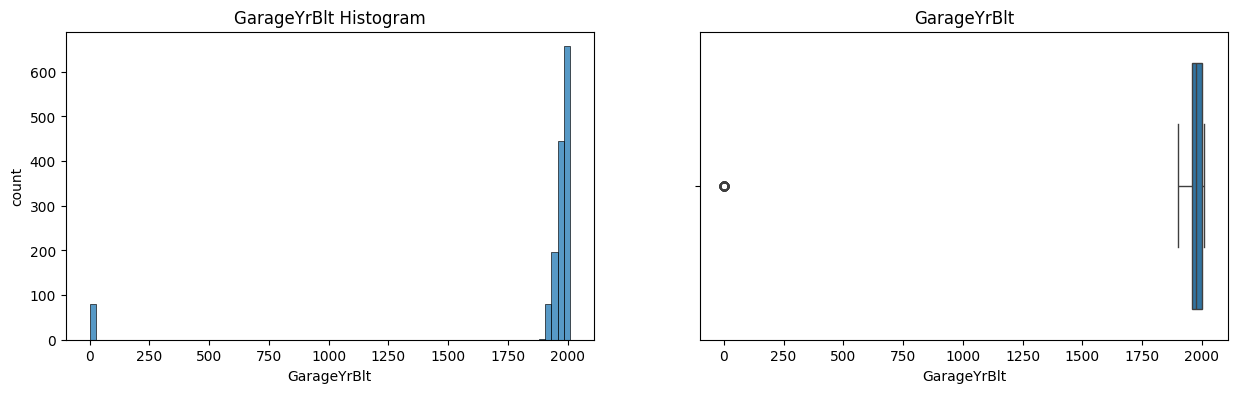

GarageCars
Skew : -0.34


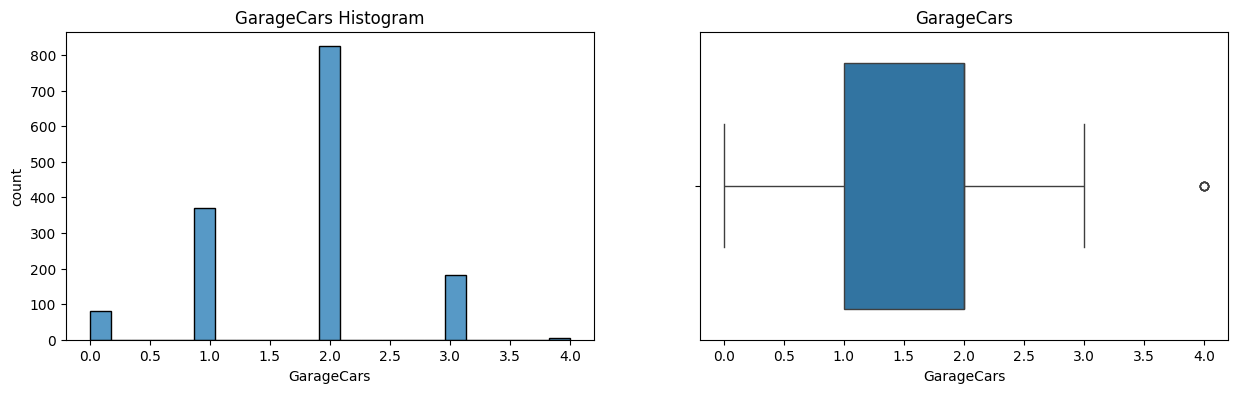

GarageArea
Skew : 0.18


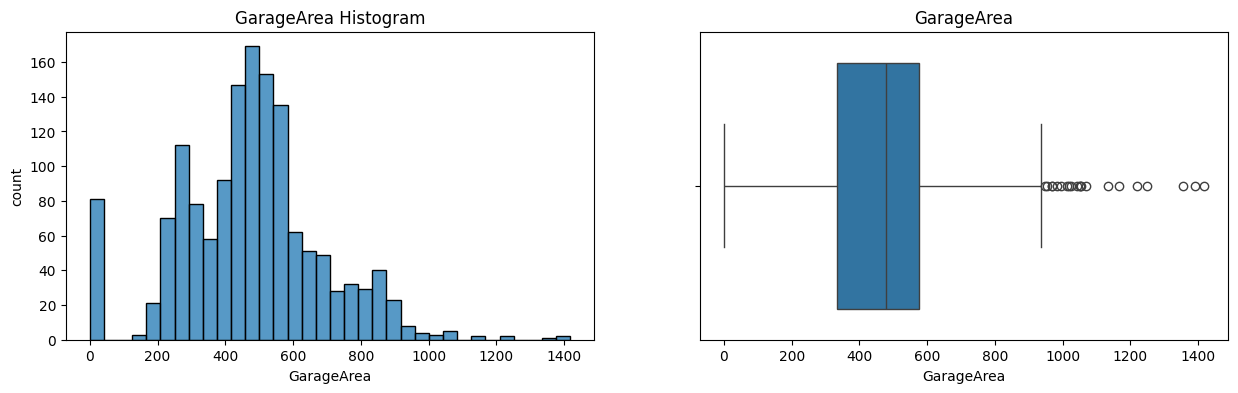

WoodDeckSF
Skew : 1.54


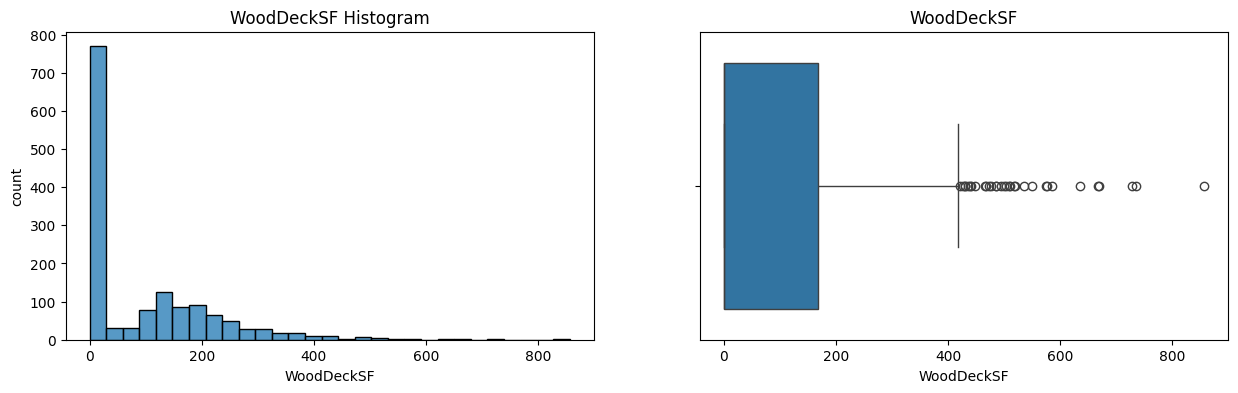

OpenPorchSF
Skew : 2.36


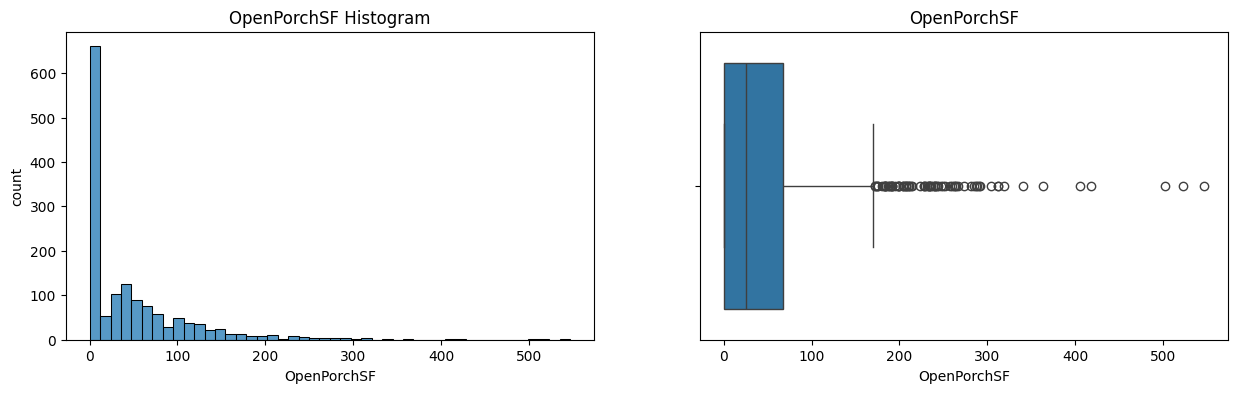

EnclosedPorch
Skew : 3.09


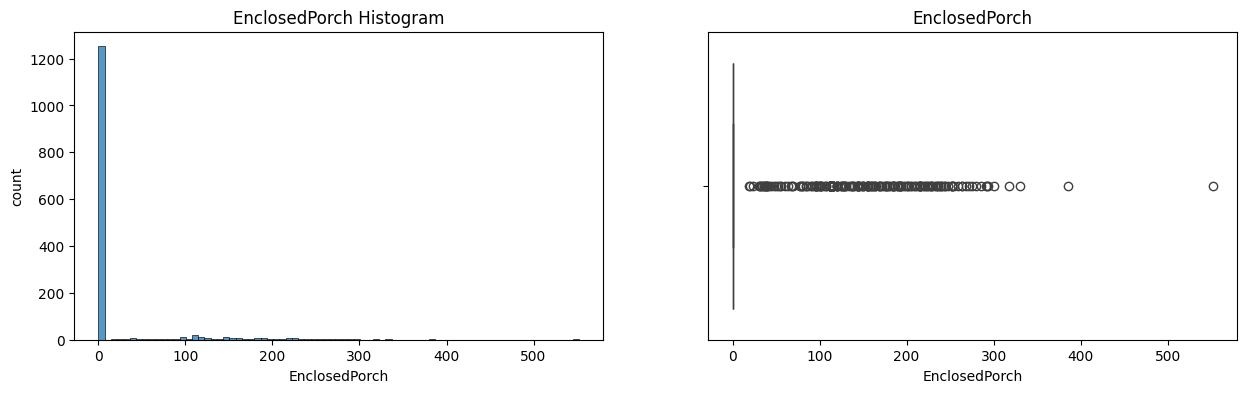

3SsnPorch
Skew : 10.3


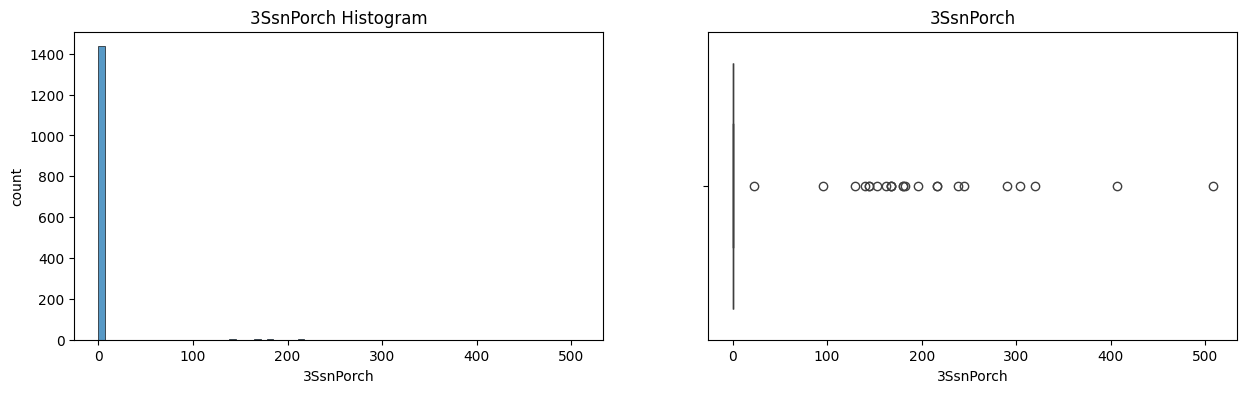

ScreenPorch
Skew : 4.12


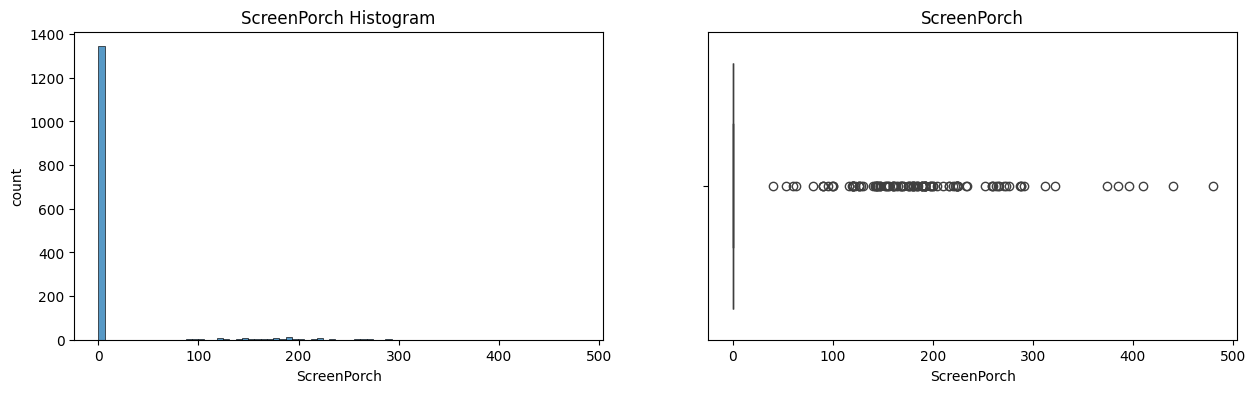

PoolArea
Skew : 14.83


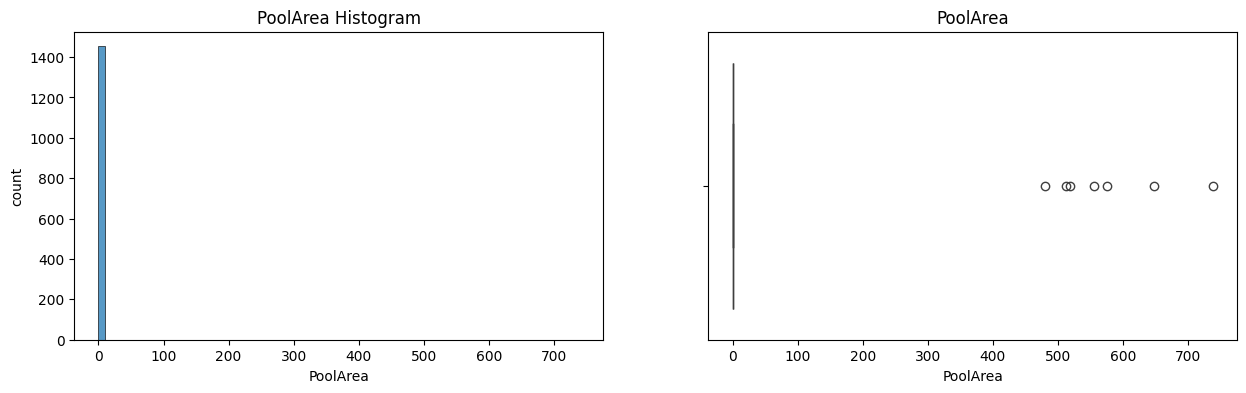

MiscVal
Skew : 24.48


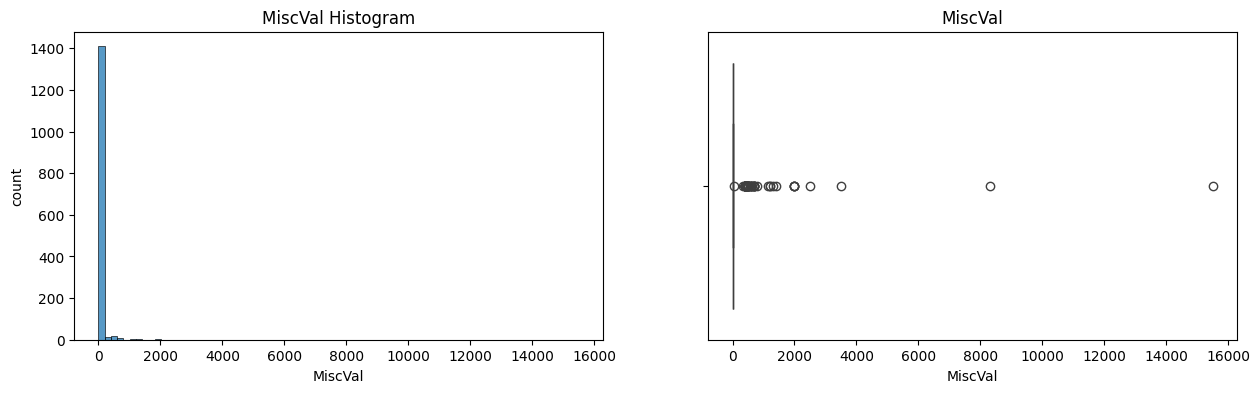

MoSold
Skew : 0.21


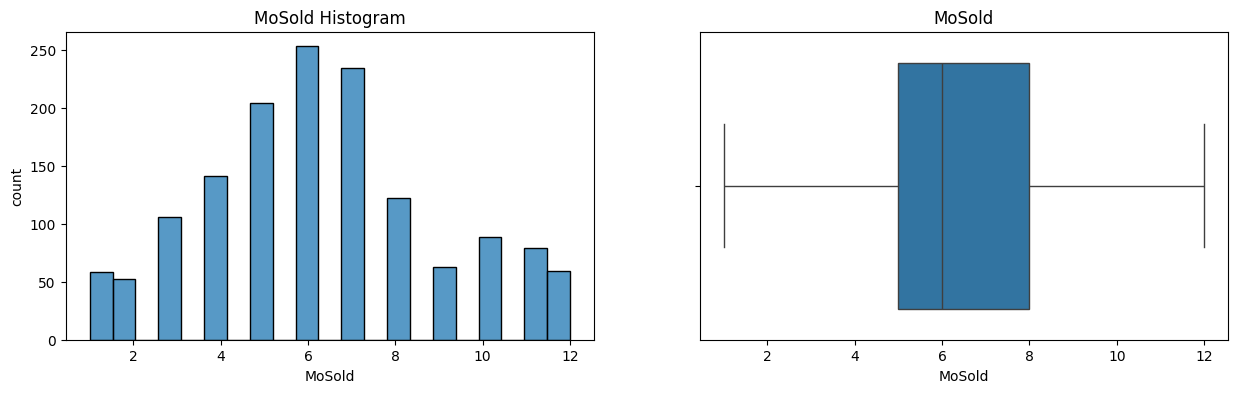

YrSold
Skew : 0.1


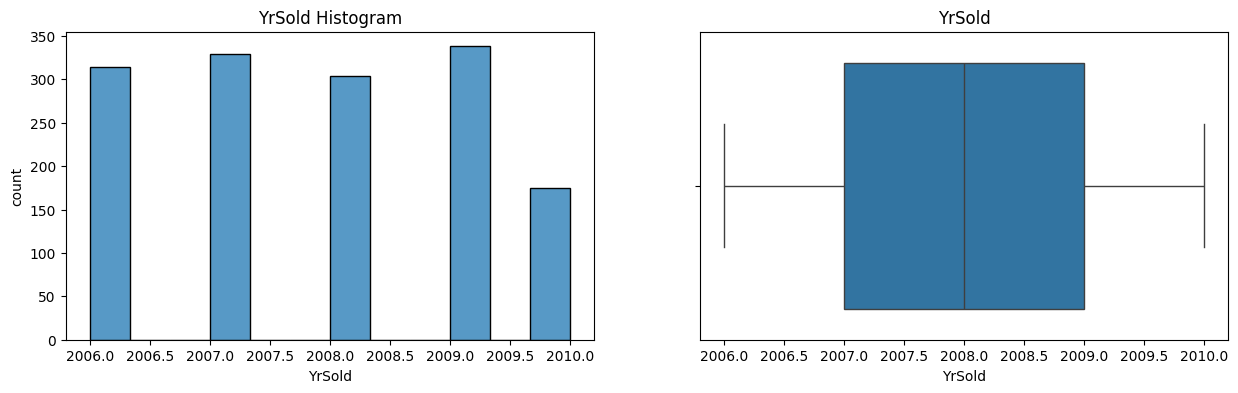

SalePrice
Skew : 1.88


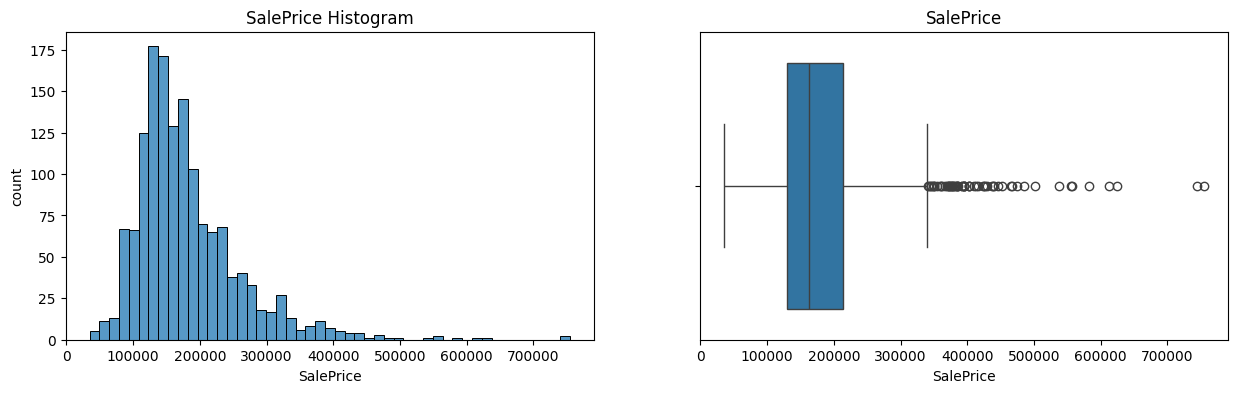

YearBuilt_AGE
Skew : 0.61


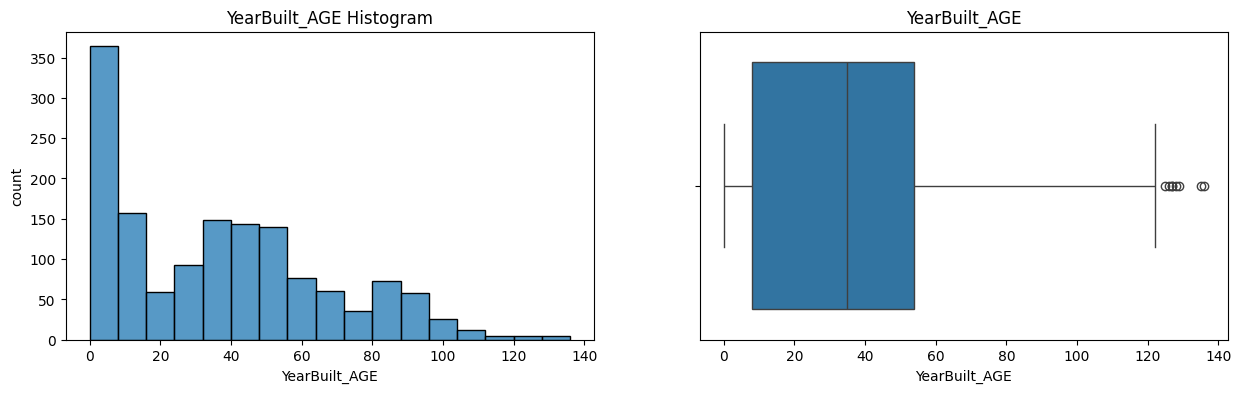

YearReMod_AGE
Skew : 0.5


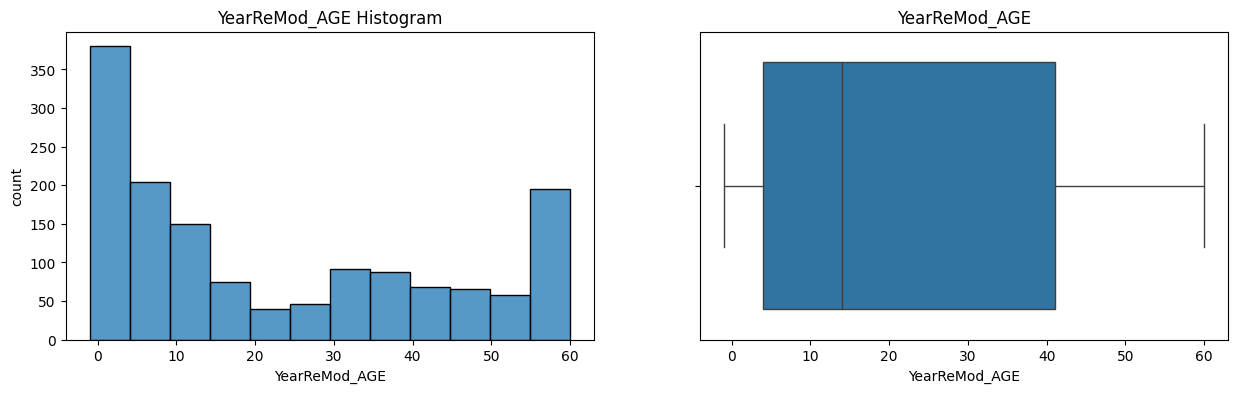

GarageYrBlt_AGE
Skew : 3.87


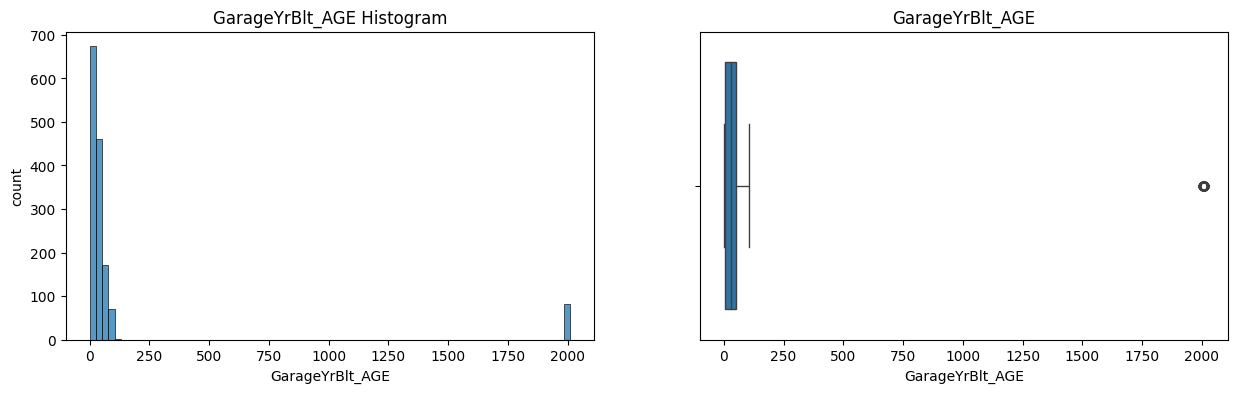

WasReModded
Skew : 0.09


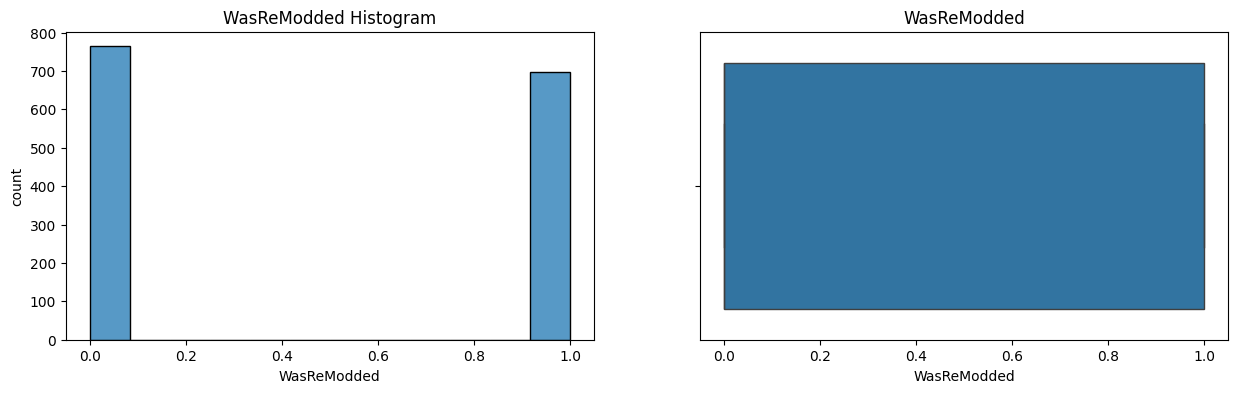

In [ ]:
for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize=(15, 4))
    
    # Histograms
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col)
    plt.ylabel('count')
    plt.title(f'{col} Histogram')
    
    # Boxplot without outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'{col}')
    
    plt.show()

# End